In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler


# Load the dataset
df = pd.read_csv('spotify_emeritus.csv')
print(f"Original shape: {df.shape}")

# Check for missing values
print("\nMissing values before removal:")
print(df.isnull().sum().sum(), "total missing values")

# Find and display records with missing values
missing_mask = df.isnull().any(axis=1)
print(f"\nRecords with missing values: {missing_mask.sum()}")

if missing_mask.sum() > 0:
    print("\nRecords with empty values:")
    print(df[missing_mask])
    
    # Remove records with ANY missing values
    df = df.dropna(how='any')
    print(f"\nAfter removal - Shape: {df.shape}")
    print("Missing values after removal:", df.isnull().sum().sum())
    
    # Verify removal
    print(f"\nSuccessfully removed {missing_mask.sum()} records with missing values")
else:
    print("No missing values found")


Original shape: (114000, 21)

Missing values before removal:
3 total missing values

Records with missing values: 1

Records with empty values:
       Unnamed: 0                track_id artists album_name track_name  \
65900       65900  1kR4gIb7nGxHPI3D2ifs59     NaN        NaN        NaN   

       popularity  duration_ms  explicit  danceability  energy  ...  loudness  \
65900           0            0     False         0.501   0.583  ...     -9.46   

       mode  speechiness  acousticness  instrumentalness  liveness  valence  \
65900     0       0.0605          0.69           0.00396    0.0747    0.734   

         tempo  time_signature  track_genre  
65900  138.391               4        k-pop  

[1 rows x 21 columns]

After removal - Shape: (113999, 21)
Missing values after removal: 0

Successfully removed 1 records with missing values


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113999 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        113999 non-null  int64  
 1   track_id          113999 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        113999 non-null  int64  
 6   duration_ms       113999 non-null  int64  
 7   explicit          113999 non-null  bool   
 8   danceability      113999 non-null  float64
 9   energy            113999 non-null  float64
 10  key               113999 non-null  int64  
 11  loudness          113999 non-null  float64
 12  mode              113999 non-null  int64  
 13  speechiness       113999 non-null  float64
 14  acousticness      113999 non-null  float64
 15  instrumentalness  113999 non-null  float64
 16  liveness          113999 

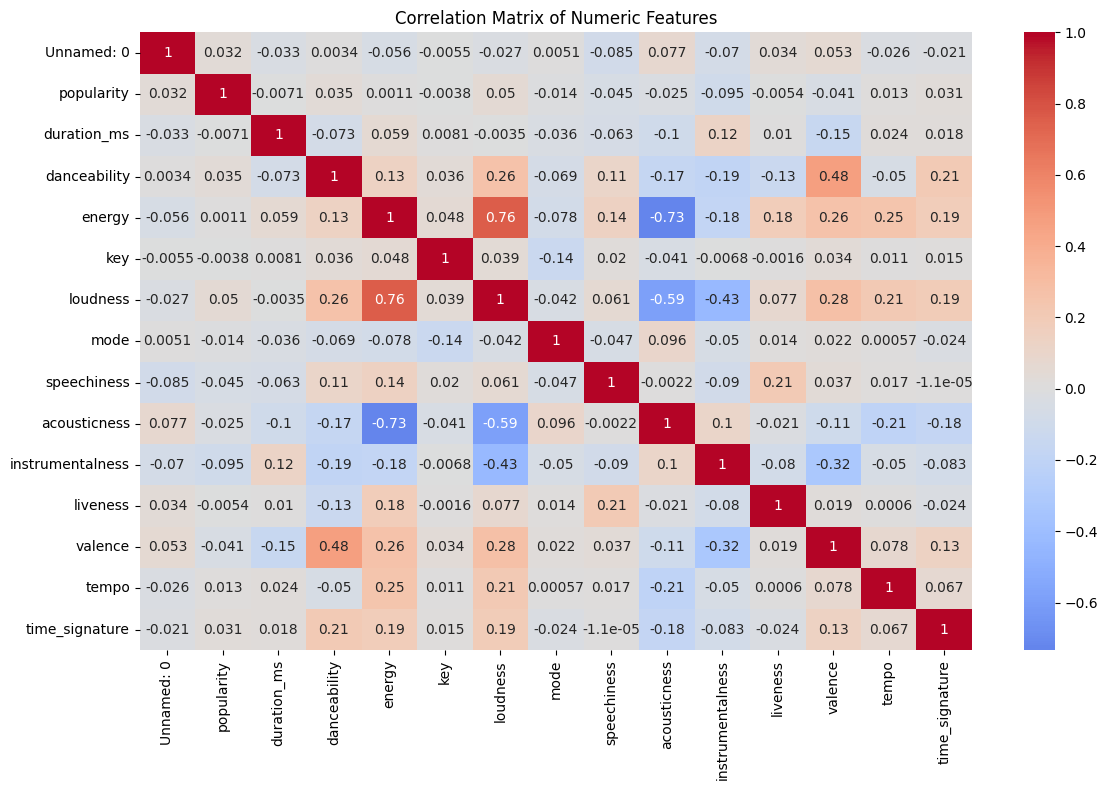

In [18]:
# Select numeric columns
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Create correlation matrix
correlation_matrix = df[numeric_columns].corr()

# Create heatmap using seaborn
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()


In [19]:
# Drop the 'Unnamed' column if it exists
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)
    print("Dropped 'Unnamed: 0' column")


Dropped 'Unnamed: 0' column


Basic Statistics of Song Popularity:
count    113999.000000
mean         33.238827
std          22.304959
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64


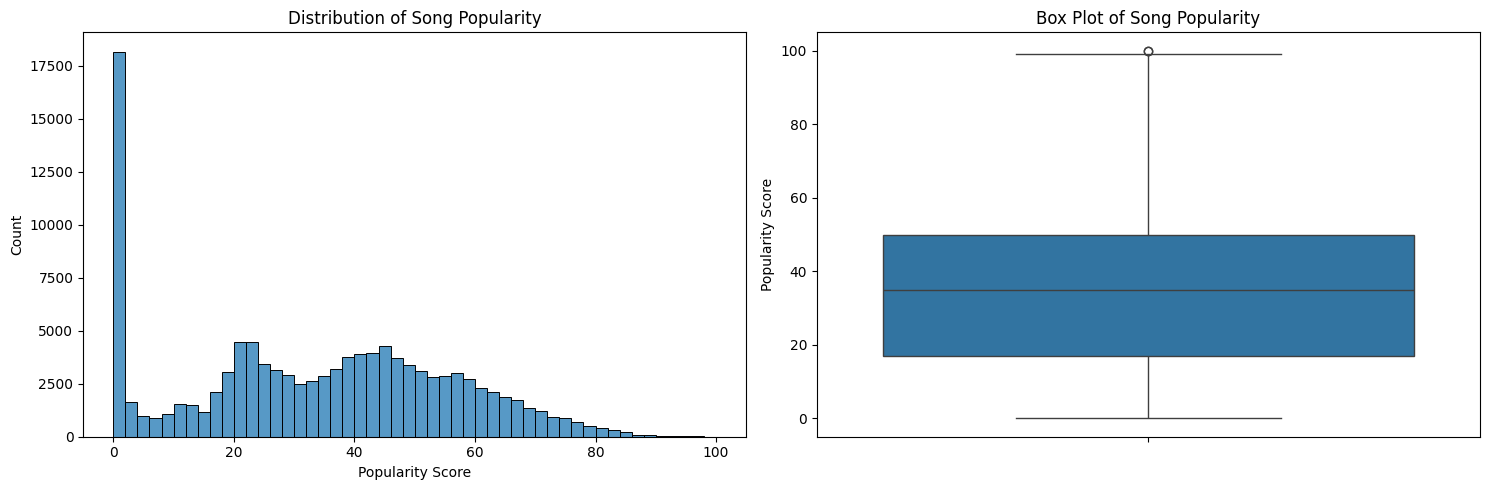


Popularity Quartiles:
0.25    17.0
0.50    35.0
0.75    50.0
Name: popularity, dtype: float64

Percentage of songs in popularity ranges:
0-20: 29.98%
20-40: 30.93%
40-60: 30.72%
60-80: 12.17%
80-100: 1.05%


In [20]:
# 1. Target Variable Analysis (Popularity)

# Basic statistics of popularity
print("Basic Statistics of Song Popularity:")
print(df['popularity'].describe())

# Create a figure with subplots
plt.figure(figsize=(15, 5))

# Plot 1: Histogram of popularity distribution
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='popularity', bins=50)
plt.title('Distribution of Song Popularity')
plt.xlabel('Popularity Score')
plt.ylabel('Count')

# Plot 2: Box plot of popularity
plt.subplot(1, 2, 2)
sns.boxplot(y=df['popularity'])
plt.title('Box Plot of Song Popularity')
plt.ylabel('Popularity Score')

plt.tight_layout()
plt.show()

# Calculate popularity quartiles for later analysis
popularity_quartiles = df['popularity'].quantile([0.25, 0.5, 0.75])
print("\nPopularity Quartiles:")
print(popularity_quartiles)

# Calculate the percentage of songs in different popularity ranges
print("\nPercentage of songs in popularity ranges:")
ranges = [(0, 20), (20, 40), (40, 60), (60, 80), (80, 100)]
for start, end in ranges:
    percentage = (df['popularity'].between(start, end).mean() * 100)
    print(f"{start}-{end}: {percentage:.2f}%")


Correlations with Popularity:
popularity          1.000000
loudness            0.050420
danceability        0.035444
tempo               0.013212
energy              0.001053
liveness           -0.005397
acousticness       -0.025458
valence            -0.040522
speechiness        -0.044930
instrumentalness   -0.095147
Name: popularity, dtype: float64


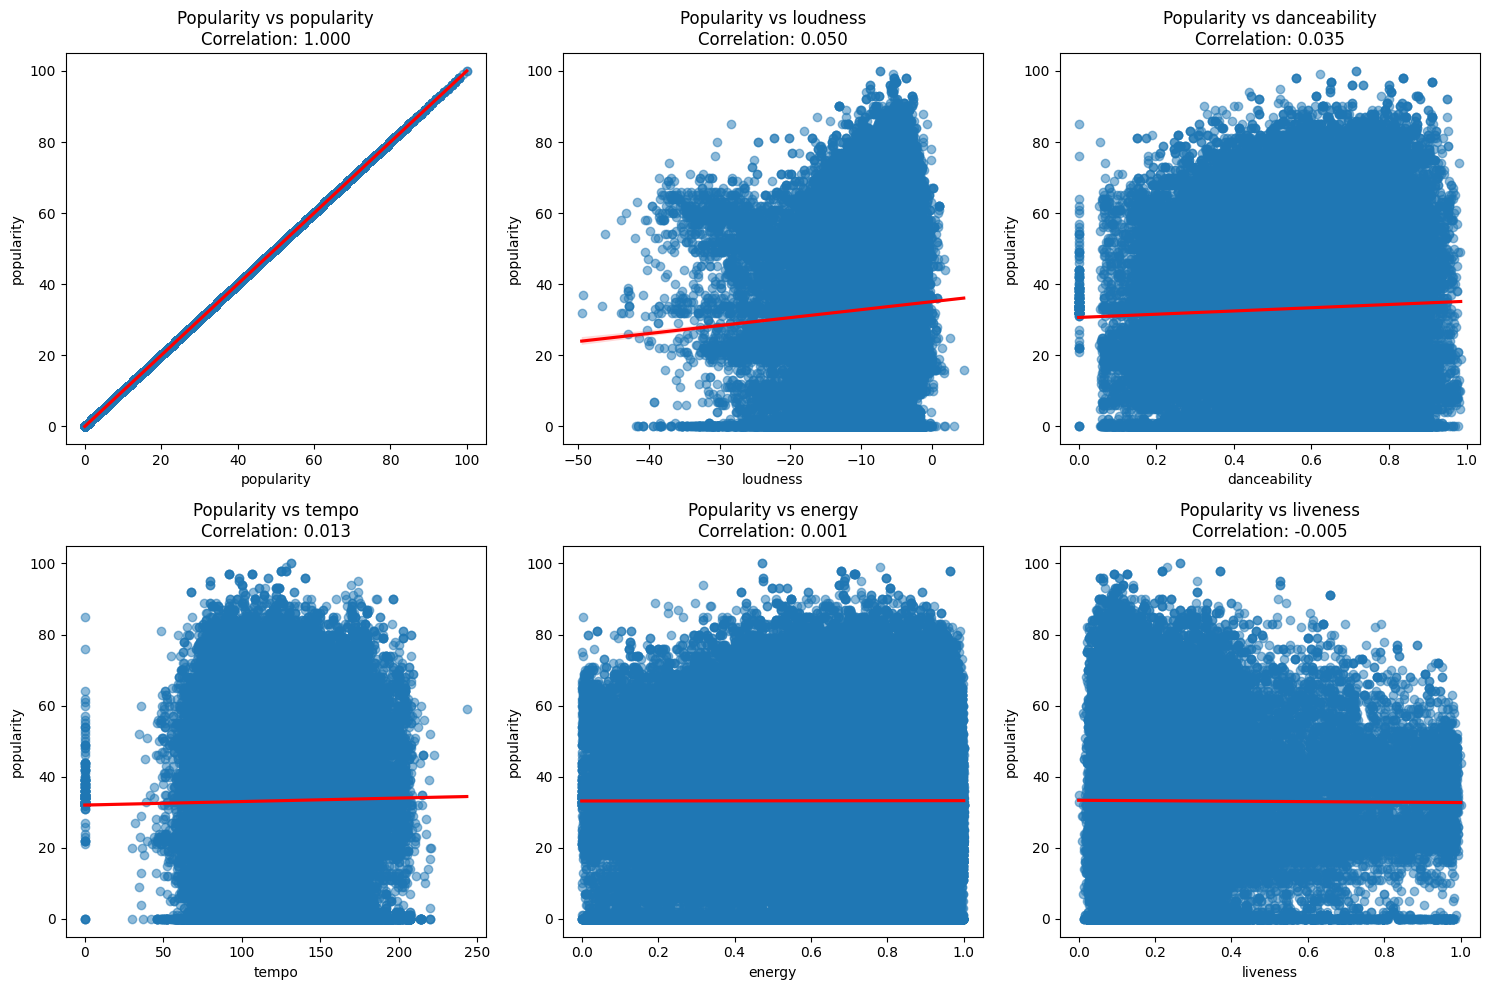


Basic Statistics of Numerical Features:
        danceability         energy       loudness    speechiness  \
count  113999.000000  113999.000000  113999.000000  113999.000000   
mean        0.566801       0.641383      -8.258950       0.084652   
std         0.173543       0.251530       5.029357       0.105733   
min         0.000000       0.000000     -49.531000       0.000000   
25%         0.456000       0.472000     -10.013000       0.035900   
50%         0.580000       0.685000      -7.004000       0.048900   
75%         0.695000       0.854000      -5.003000       0.084500   
max         0.985000       1.000000       4.532000       0.965000   

        acousticness  instrumentalness       liveness        valence  \
count  113999.000000     113999.000000  113999.000000  113999.000000   
mean        0.314907          0.156051       0.213554       0.474066   
std         0.332522          0.309556       0.190378       0.259261   
min         0.000000          0.000000       0.00

In [21]:
# 2. Analysis of Numerical Features and their Relationship with Popularity

# Select numerical features (excluding popularity and duration_ms for now)
numerical_features = ['danceability', 'energy', 'loudness', 'speechiness', 
                     'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

# Create correlation with popularity
correlations = df[numerical_features + ['popularity']].corr()['popularity'].sort_values(ascending=False)
print("Correlations with Popularity:")
print(correlations)

# Create scatter plots for top 6 correlated features
plt.figure(figsize=(15, 10))
top_features = correlations.index[:6]  # Get top 6 correlated features

for i, feature in enumerate(top_features, 1):
    plt.subplot(2, 3, i)
    
    # Create scatter plot with trend line
    sns.regplot(data=df, x=feature, y='popularity', scatter_kws={'alpha':0.5}, line_kws={'color': 'red'})
    plt.title(f'Popularity vs {feature}\nCorrelation: {correlations[feature]:.3f}')
    
plt.tight_layout()
plt.show()

# Calculate basic statistics for numerical features
print("\nBasic Statistics of Numerical Features:")
print(df[numerical_features].describe())


Number of unique genres: 114

Top 10 genres by count:
track_genre
acoustic             1000
afrobeat             1000
psych-rock           1000
progressive-house    1000
power-pop            1000
pop                  1000
pop-film             1000
piano                1000
party                1000
pagode               1000
Name: count, dtype: int64


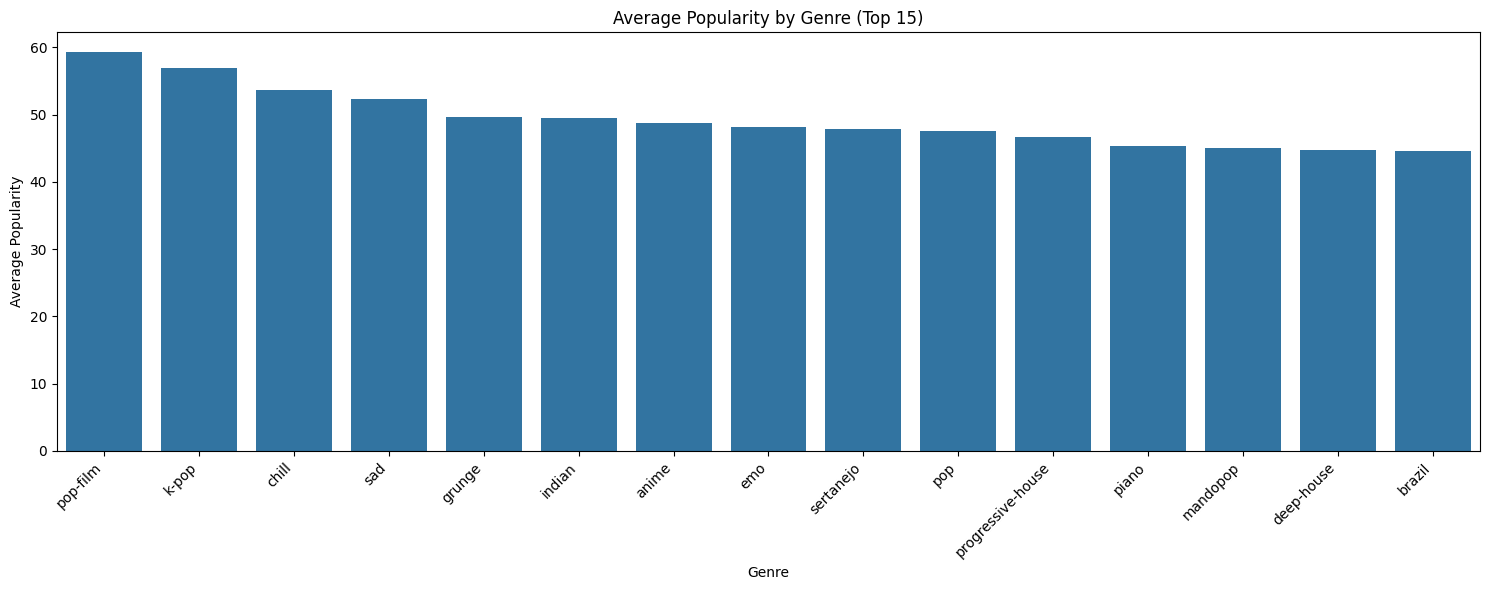

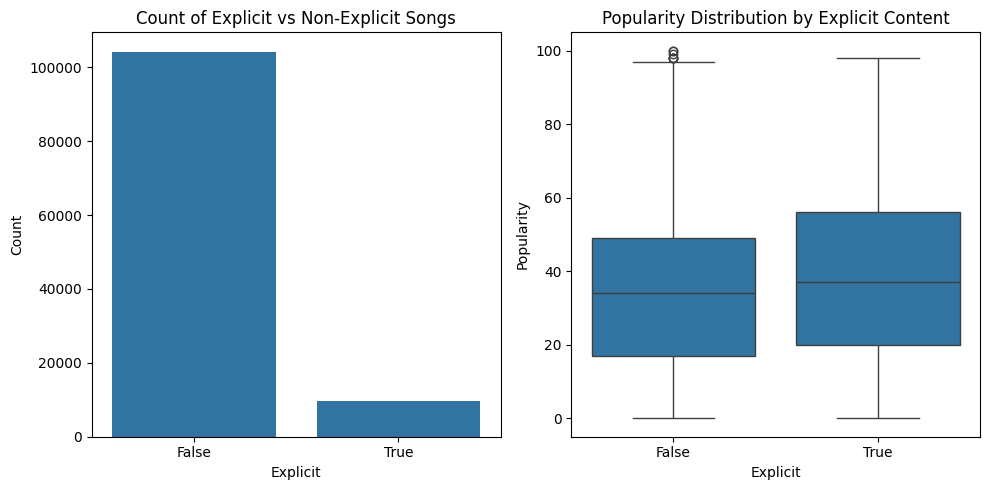


Statistics for Explicit vs Non-Explicit Songs:
           count   mean    std
explicit                      
False     104252  32.94  22.08
True        9747  36.45  24.32


In [22]:
# 3. Analysis of Categorical Features (Genre and Explicit)

# Analyze genres
print("Number of unique genres:", df['track_genre'].nunique())
print("\nTop 10 genres by count:")
print(df['track_genre'].value_counts().head(10))

# Calculate average popularity by genre
genre_popularity = df.groupby('track_genre')['popularity'].agg(['mean', 'count']).round(2)
genre_popularity = genre_popularity.sort_values('mean', ascending=False)

# Plot top 15 genres by average popularity
plt.figure(figsize=(15, 6))
top_15_genres = genre_popularity.head(15)
sns.barplot(x=top_15_genres.index, y=top_15_genres['mean'])
plt.xticks(rotation=45, ha='right')
plt.title('Average Popularity by Genre (Top 15)')
plt.xlabel('Genre')
plt.ylabel('Average Popularity')
plt.tight_layout()
plt.show()

# Analyze explicit vs non-explicit songs
plt.figure(figsize=(10, 5))

# Plot 1: Count of explicit vs non-explicit songs
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='explicit')
plt.title('Count of Explicit vs Non-Explicit Songs')
plt.xlabel('Explicit')
plt.ylabel('Count')

# Plot 2: Box plot of popularity by explicit
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='explicit', y='popularity')
plt.title('Popularity Distribution by Explicit Content')
plt.xlabel('Explicit')
plt.ylabel('Popularity')

plt.tight_layout()
plt.show()

# Print statistics about explicit vs non-explicit songs
print("\nStatistics for Explicit vs Non-Explicit Songs:")
print(df.groupby('explicit')['popularity'].agg(['count', 'mean', 'std']).round(2))


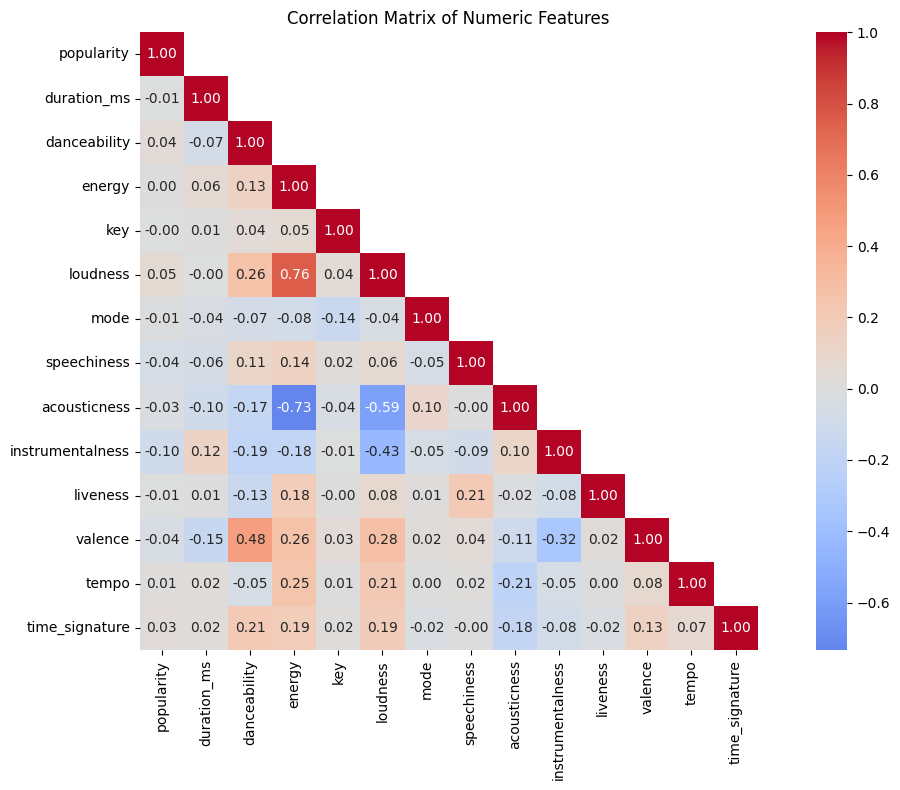


Highly correlated feature pairs (|correlation| > 0.5):
energy - loudness: 0.762
energy - acousticness: -0.734
loudness - acousticness: -0.590


In [23]:
# 4. Feature Correlation Analysis for Multicollinearity

# Create correlation matrix for all numeric features
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numeric_cols].corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(correlation_matrix), k=1)

# Create heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f',
            square=True)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

# Identify highly correlated feature pairs (|correlation| > 0.5)
print("\nHighly correlated feature pairs (|correlation| > 0.5):")
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i,j]) > 0.5:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i,j]
            ))

# Sort by absolute correlation value
high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

# Print the highly correlated pairs
for feat1, feat2, corr in high_corr_pairs:
    print(f"{feat1} - {feat2}: {corr:.3f}")


In [24]:
# 5. Feature Engineering

# Create a copy of the dataframe for feature engineering
df_engineered = df.copy()

# 1. Create popularity bins for classification
print("Creating popularity bins...")
df_engineered['popularity_class'] = pd.cut(df_engineered['popularity'], 
                                         bins=[0, 20, 40, 60, 80, 100],
                                         labels=['very_low', 'low', 'medium', 'high', 'very_high'])

df_engineered['is_hit'] = (df_engineered['popularity'] > 60).astype(int)

print("\nPopularity Class Distribution:")
print(df_engineered['popularity_class'].value_counts(normalize=True).round(3) * 100)
print("\nHit vs Non-Hit Distribution:")
print(df_engineered['is_hit'].value_counts(normalize=True).round(3) * 100)

# 2. Handle multicollinearity in audio features
# Create composite features from correlated pairs
print("\nCreating composite features...")
df_engineered['energy_loudness_composite'] = (
    df_engineered['energy'] * df_engineered['loudness'].clip(lower=0)  # Clip negative values
).fillna(0)

df_engineered['energy_acousticness_ratio'] = (
    df_engineered['energy'] / (df_engineered['acousticness'] + 0.01)  # Add small constant to avoid division by zero
)

# 3. Genre encoding using target encoding
print("\nEncoding genres...")
# Calculate mean popularity per genre
genre_popularity_mean = df_engineered.groupby('track_genre')['popularity'].mean()
df_engineered['genre_popularity_encoding'] = df_engineered['track_genre'].map(genre_popularity_mean)

# 4. Feature scaling
print("\nScaling numerical features...")
features_to_scale = ['danceability', 'energy', 'loudness', 'speechiness', 
                     'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
                     'energy_loudness_composite', 'energy_acousticness_ratio']

scaler = StandardScaler()
df_engineered[features_to_scale] = scaler.fit_transform(df_engineered[features_to_scale])

# 5. Create interaction features
print("\nCreating interaction features...")
df_engineered['danceability_energy'] = df_engineered['danceability'] * df_engineered['energy']
df_engineered['valence_energy'] = df_engineered['valence'] * df_engineered['energy']
df_engineered['loudness_danceability'] = df_engineered['loudness'] * df_engineered['danceability']

# 6. Duration feature transformation
print("\nTransforming duration...")
df_engineered['duration_minutes'] = df_engineered['duration_ms'] / 60000
df_engineered['duration_minutes_log'] = np.log1p(df_engineered['duration_minutes'])

# Display summary of new features
print("\nNew features summary:")
new_features = ['energy_loudness_composite', 'energy_acousticness_ratio', 
                'genre_popularity_encoding', 'danceability_energy', 
                'valence_energy', 'loudness_danceability', 
                'duration_minutes', 'duration_minutes_log']

print(df_engineered[new_features].describe().round(3))

# Correlation of new features with popularity
print("\nCorrelations of new features with popularity:")
correlations = df_engineered[new_features + ['popularity']].corr()['popularity'].sort_values(ascending=False)
print(correlations.round(3))


Creating popularity bins...

Popularity Class Distribution:
popularity_class
low          33.8
medium       33.8
very_low     18.5
high         12.9
very_high     1.0
Name: proportion, dtype: float64

Hit vs Non-Hit Distribution:
is_hit
0    88.1
1    11.9
Name: proportion, dtype: float64

Creating composite features...

Encoding genres...

Scaling numerical features...

Creating interaction features...

Transforming duration...

New features summary:
       energy_loudness_composite  energy_acousticness_ratio  \
count                 113999.000                 113999.000   
mean                       0.000                     -0.000   
std                        1.000                      1.000   
min                       -0.020                     -0.681   
25%                       -0.020                     -0.651   
50%                       -0.020                     -0.554   
75%                       -0.020                      0.269   
max                      174.427        

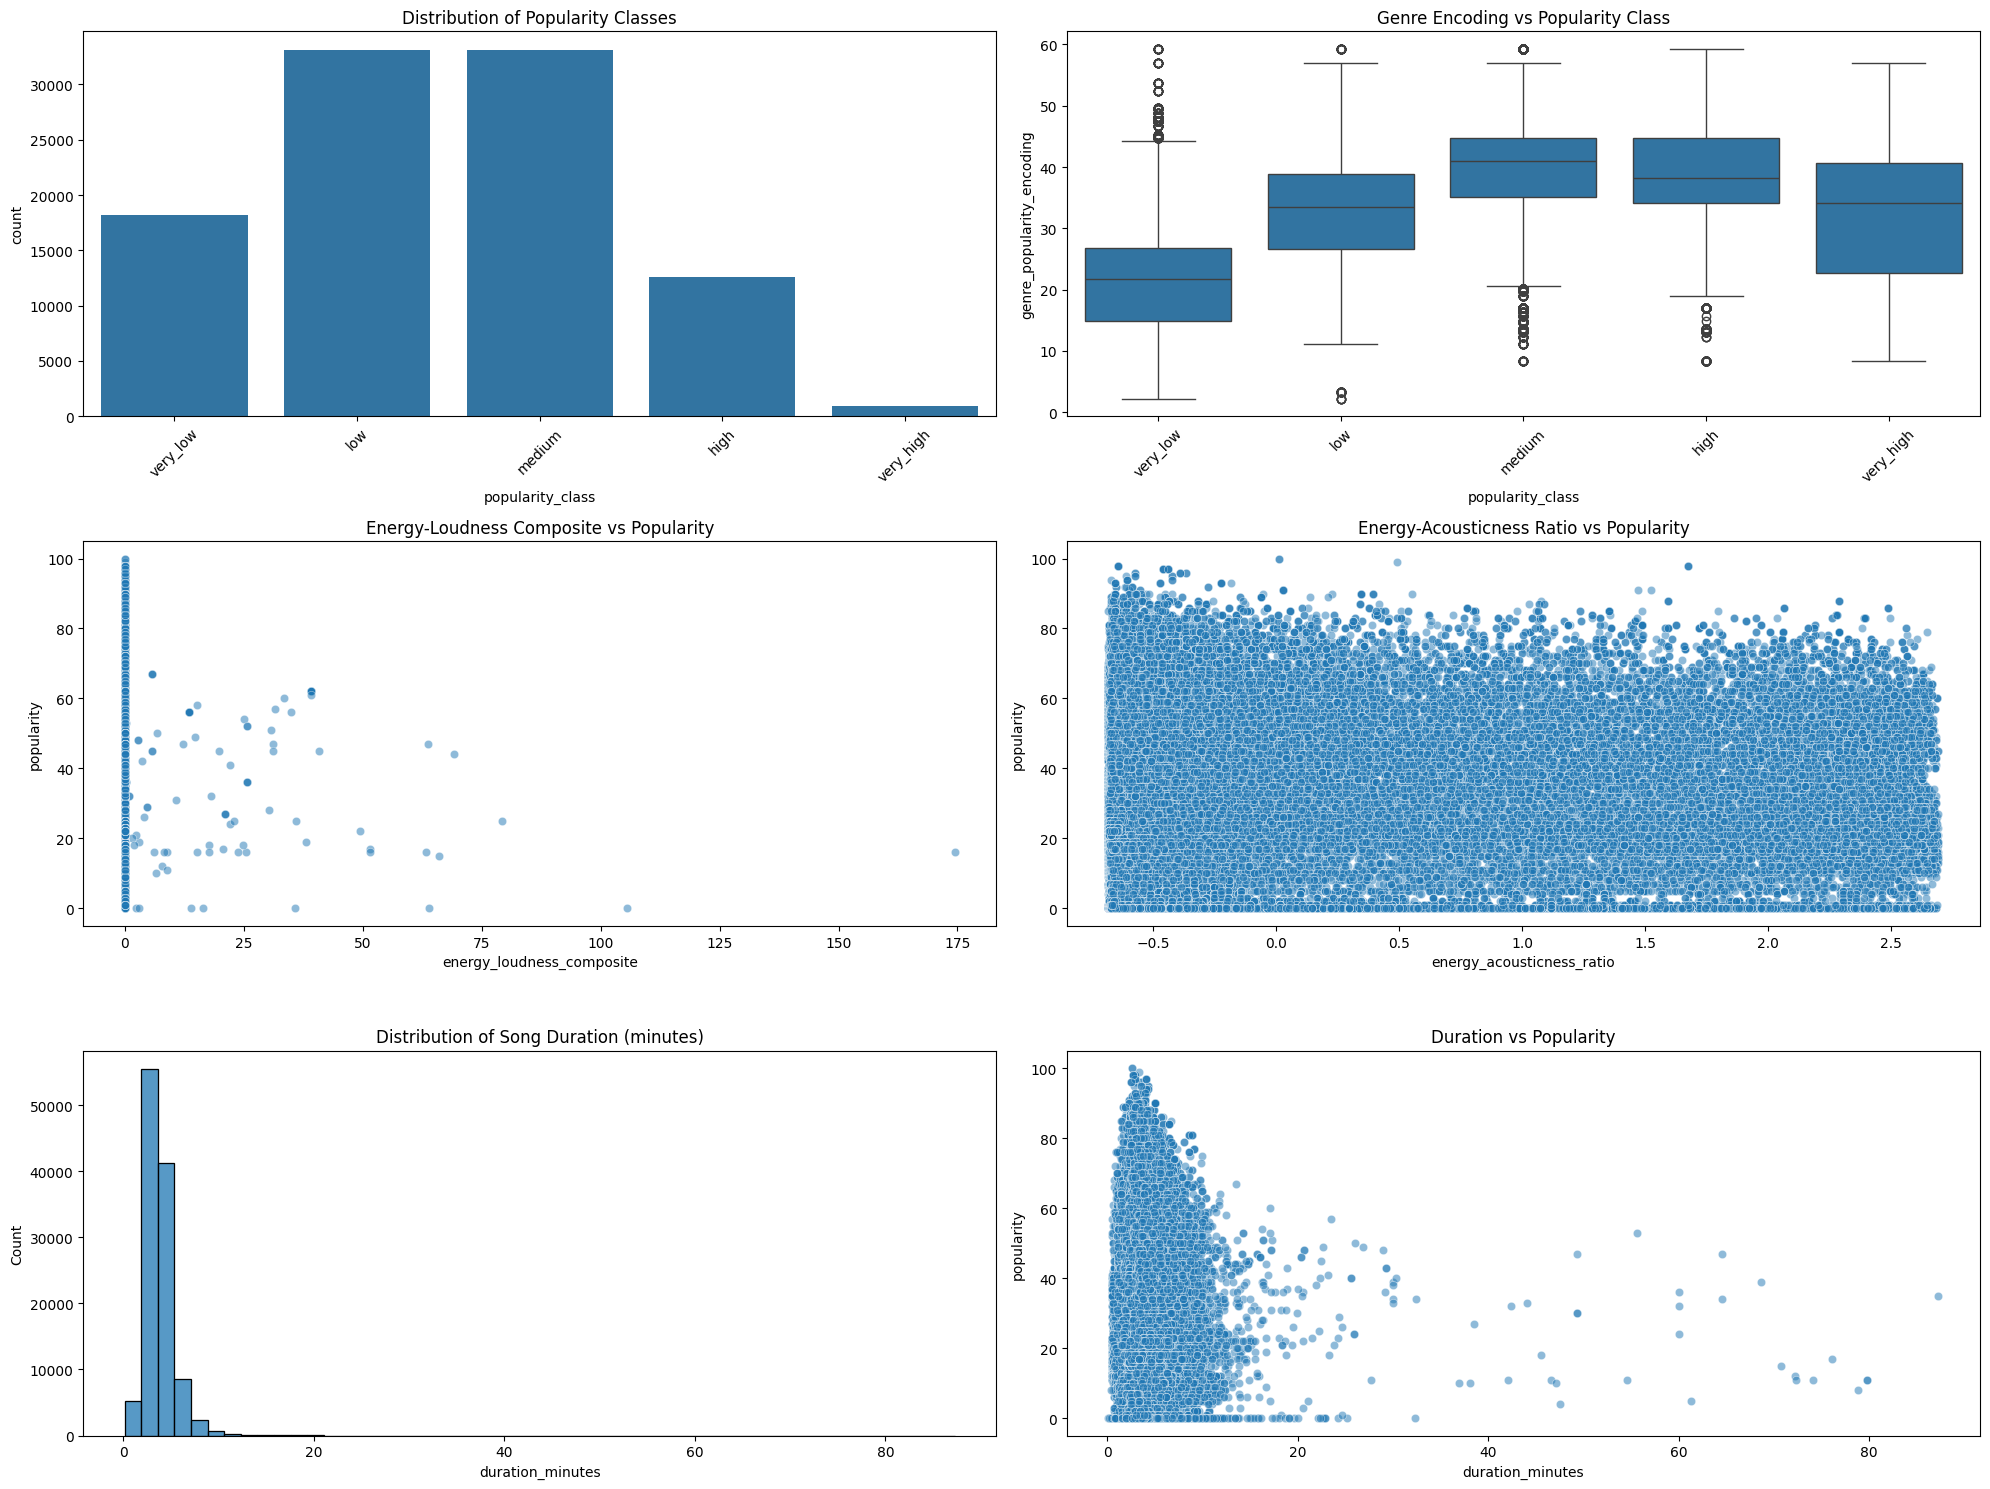

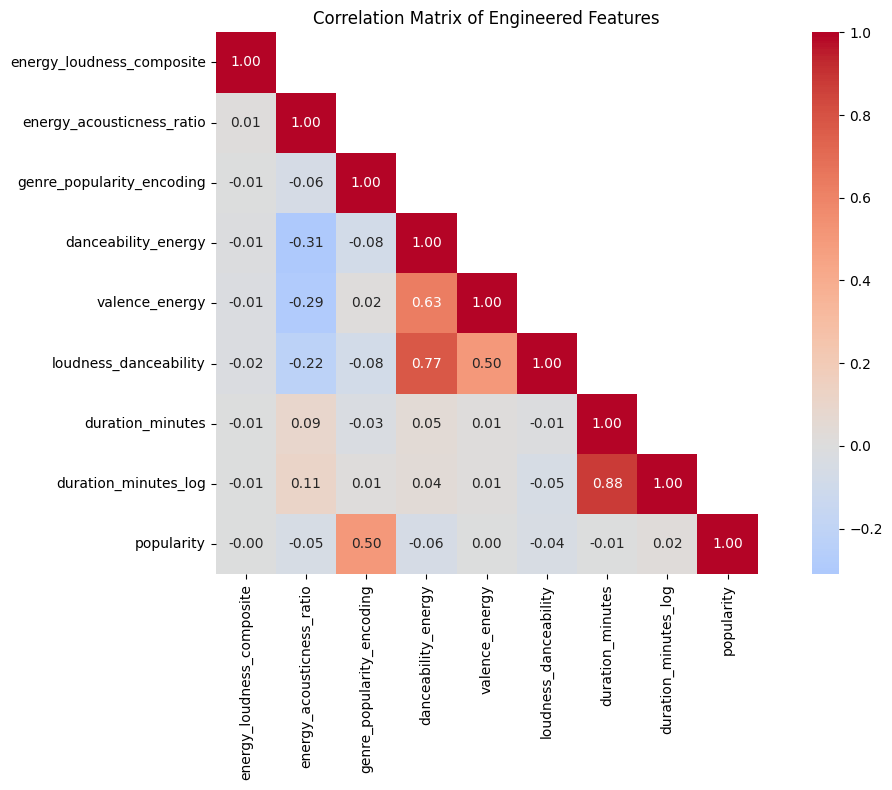


Engineered Features Statistics by Hit Status:
       energy_loudness_composite        energy_acousticness_ratio         \
                            mean    std                      mean    std   
is_hit                                                                     
0                         -0.000  1.013                     0.009  1.014   
1                          0.002  0.895                    -0.067  0.884   

       genre_popularity_encoding         danceability_energy         \
                            mean     std                mean    std   
is_hit                                                                
0                         32.491  11.176               0.139  1.204   
1                         38.770  10.168               0.103  0.990   

       valence_energy        loudness_danceability        duration_minutes  \
                 mean    std                  mean    std             mean   
is_hit                                                      

In [25]:
# 6. Analyzing Engineered Features

# Create a figure with multiple subplots
plt.figure(figsize=(20, 15))

# 1. Distribution of popularity classes
plt.subplot(3, 2, 1)
sns.countplot(data=df_engineered, x='popularity_class')
plt.title('Distribution of Popularity Classes')
plt.xticks(rotation=45)

# 2. Box plot of genre popularity encoding by popularity class
plt.subplot(3, 2, 2)
sns.boxplot(data=df_engineered, x='popularity_class', y='genre_popularity_encoding')
plt.title('Genre Encoding vs Popularity Class')
plt.xticks(rotation=45)

# 3. Scatter plot of energy_loudness_composite vs popularity
plt.subplot(3, 2, 3)
sns.scatterplot(data=df_engineered, x='energy_loudness_composite', y='popularity', alpha=0.5)
plt.title('Energy-Loudness Composite vs Popularity')

# 4. Scatter plot of energy_acousticness_ratio vs popularity
plt.subplot(3, 2, 4)
sns.scatterplot(data=df_engineered, x='energy_acousticness_ratio', y='popularity', alpha=0.5)
plt.title('Energy-Acousticness Ratio vs Popularity')

# 5. Duration distribution
plt.subplot(3, 2, 5)
sns.histplot(data=df_engineered, x='duration_minutes', bins=50)
plt.title('Distribution of Song Duration (minutes)')

# 6. Duration vs Popularity
plt.subplot(3, 2, 6)
sns.scatterplot(data=df_engineered, x='duration_minutes', y='popularity', alpha=0.5)
plt.title('Duration vs Popularity')

plt.tight_layout()
plt.show()

# Create correlation heatmap for engineered features
plt.figure(figsize=(12, 8))
engineered_features = new_features + ['popularity']
correlation_matrix = df_engineered[engineered_features].corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(correlation_matrix), k=1)

# Create heatmap
sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f',
            square=True)
plt.title('Correlation Matrix of Engineered Features')
plt.tight_layout()
plt.show()

# Print summary statistics for hits vs non-hits
print("\nEngineered Features Statistics by Hit Status:")
hit_stats = df_engineered.groupby('is_hit')[new_features].agg(['mean', 'std']).round(3)
print(hit_stats)


Feature Correlations with Popularity:
                                             feature  correlation
genre_popularity_encoding  genre_popularity_encoding     0.504196
loudness                                    loudness     0.050420
danceability                            danceability     0.035444
duration_minutes_log            duration_minutes_log     0.019037
tempo                                          tempo     0.013212
energy                                        energy     0.001053
valence_energy                        valence_energy     0.000725
energy_loudness_composite  energy_loudness_composite    -0.000979
liveness                                    liveness    -0.005397
acousticness                            acousticness    -0.025458
valence                                      valence    -0.040522
loudness_danceability          loudness_danceability    -0.044421
speechiness                              speechiness    -0.044930
energy_acousticness_ratio  energy_acou

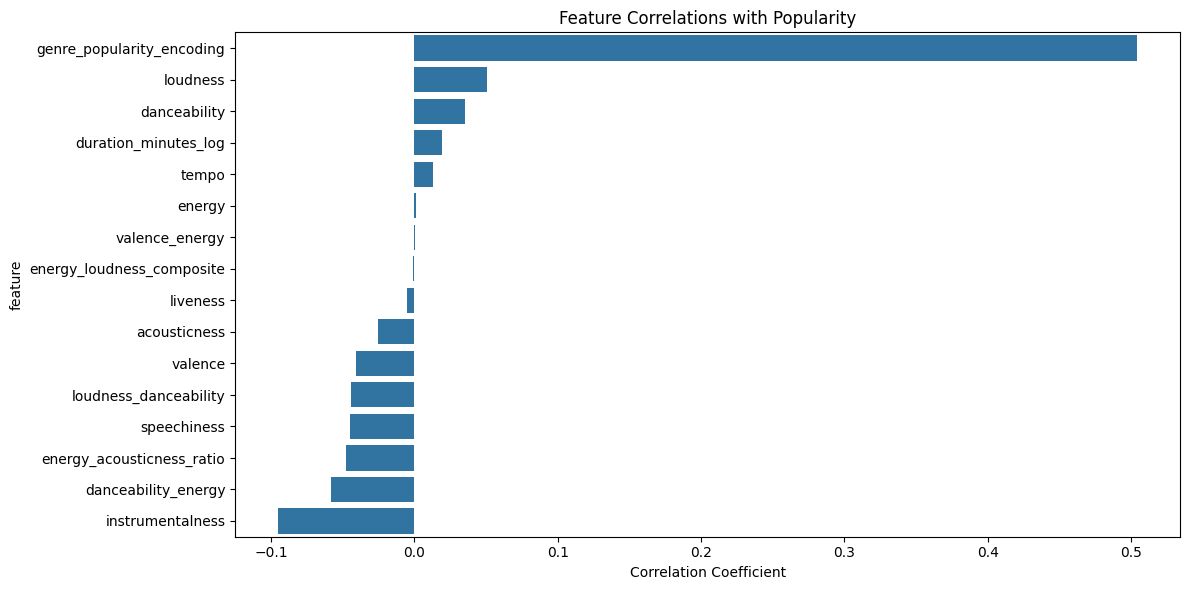

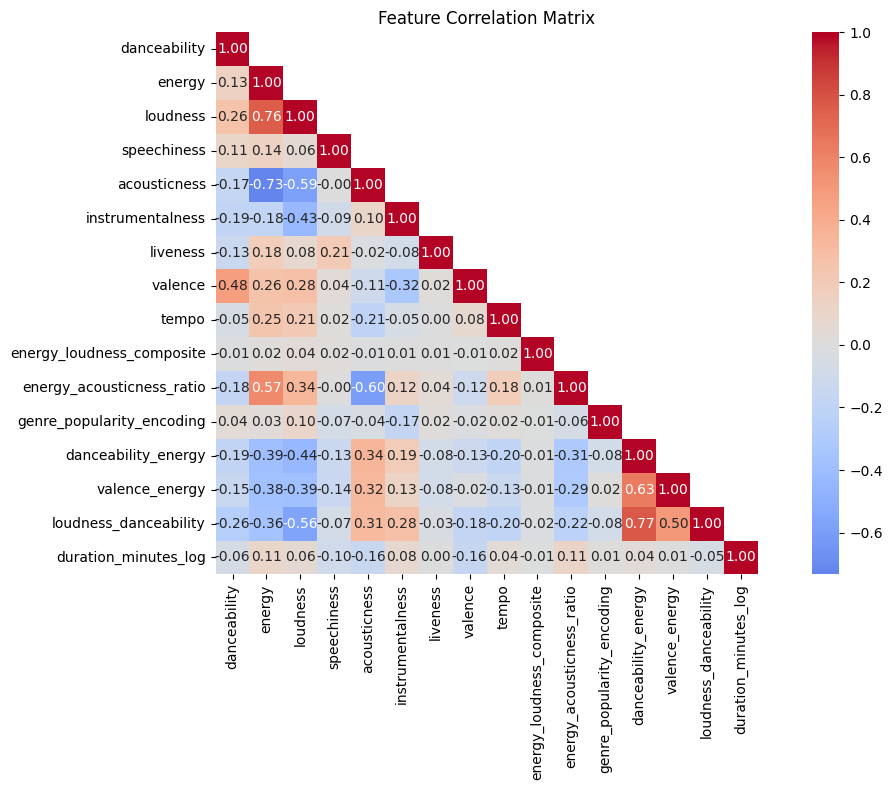


Missing Values:
danceability                 0
energy                       0
loudness                     0
speechiness                  0
acousticness                 0
instrumentalness             0
liveness                     0
valence                      0
tempo                        0
energy_loudness_composite    0
energy_acousticness_ratio    0
genre_popularity_encoding    0
danceability_energy          0
valence_energy               0
loudness_danceability        0
duration_minutes_log         0
dtype: int64


In [26]:
# Prepare data for regression modeling

# Remove classification-related columns and keep only relevant features
regression_features = [
    # Original audio features
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
    
    # Engineered features
    'energy_loudness_composite', 'energy_acousticness_ratio',
    'genre_popularity_encoding', 'danceability_energy',
    'valence_energy', 'loudness_danceability',
    'duration_minutes_log'
]

# Create feature matrix X and target variable y
X = df_engineered[regression_features]
y = df_engineered['popularity']

# Display correlation with target variable
correlations = pd.DataFrame({
    'feature': regression_features,
    'correlation': X.corrwith(y)
}).sort_values('correlation', ascending=False)

print("Feature Correlations with Popularity:")
print(correlations)

# Basic statistics of our features
print("\nFeature Statistics:")
print(X.describe().round(3))

# Visualize feature importance based on correlation
plt.figure(figsize=(12, 6))
sns.barplot(data=correlations, x='correlation', y='feature')
plt.title('Feature Correlations with Popularity')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

# Create a correlation matrix heatmap for features
plt.figure(figsize=(12, 8))
correlation_matrix = X.corr()
mask = np.triu(np.ones_like(correlation_matrix), k=1)
sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f',
            square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Check for any remaining missing values
print("\nMissing Values:")
print(X.isnull().sum())


In [ ]:
# Set up regression models and evaluation

from sklearn.model_selection import train_test_split, KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models
models = {
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42)
}

# Set up K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Dictionary to store results
results = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Initialize lists to store fold scores
    fold_rmse = []
    
    # Perform manual k-fold cross-validation
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        # Split data for this fold
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]
        y_fold_val = y_train.iloc[val_idx]
        
        # Train model
        model.fit(X_fold_train, y_fold_train)
        
        # Make predictions
        y_fold_pred = model.predict(X_fold_val)
        
        # Calculate RMSE for this fold
        fold_rmse.append(np.sqrt(mean_squared_error(y_fold_val, y_fold_pred)))
        
    # Calculate cross-validation statistics
    cv_rmse_mean = np.mean(fold_rmse)
    cv_rmse_std = np.std(fold_rmse)
    
    # Train model on full training set
    model.fit(X_train, y_train)
    
    # Make predictions on test set
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Store results
    results[name] = {
        'cv_rmse_mean': cv_rmse_mean,
        'cv_rmse_std': cv_rmse_std,
        'test_rmse': rmse,
        'test_mae': mae,
        'test_r2': r2
    }
    
    print(f"{name} Results:")
    print(f"Cross-validation RMSE: {cv_rmse_mean:.2f} (+/- {cv_rmse_std*2:.2f})")
    print(f"Test RMSE: {rmse:.2f}")
    print(f"Test MAE: {mae:.2f}")
    print(f"Test R²: {r2:.3f}")

# Create feature importance plots for each model
plt.figure(figsize=(15, 5))

# Plot for Decision Tree
plt.subplot(1, 3, 1)
importances_dt = pd.Series(models['Decision Tree'].feature_importances_, index=regression_features)
importances_dt.sort_values(ascending=True).plot(kind='barh')
plt.title('Decision Tree\nFeature Importance')
plt.xlabel('Importance')

# Plot for Random Forest
plt.subplot(1, 3, 2)
importances_rf = pd.Series(models['Random Forest'].feature_importances_, index=regression_features)
importances_rf.sort_values(ascending=True).plot(kind='barh')
plt.title('Random Forest\nFeature Importance')
plt.xlabel('Importance')

# Plot for XGBoost
plt.subplot(1, 3, 3)
importances_xgb = pd.Series(models['XGBoost'].feature_importances_, index=regression_features)
importances_xgb.sort_values(ascending=True).plot(kind='barh')
plt.title('XGBoost\nFeature Importance')
plt.xlabel('Importance')

plt.tight_layout()
plt.show()

# Compare actual vs predicted values for the best model
best_model_name = min(results, key=lambda x: results[x]['test_rmse'])
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Popularity')
plt.ylabel('Predicted Popularity')
plt.title(f'Actual vs Predicted Popularity\n{best_model_name}')
plt.tight_layout()
plt.show()

# Print feature importance summary
print("\nTop 5 Most Important Features by Model:")
for name in models.keys():
    importances = pd.Series(models[name].feature_importances_, index=regression_features)
    print(f"\n{name}:")
    print(importances.sort_values(ascending=False).head())


In [27]:
# Set up regression models and evaluation

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models
models = {
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(random_state=42, objective='reg:squarederror')
}

# Set up K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Dictionary to store results
results = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Perform cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=kf, 
                               scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-cv_scores)
    
    # Train model on full training set
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Store results
    results[name] = {
        'cv_rmse_mean': rmse_scores.mean(),
        'cv_rmse_std': rmse_scores.std(),
        'test_rmse': rmse,
        'test_mae': mae,
        'test_r2': r2
    }
    
    print(f"{name} Results:")
    print(f"Cross-validation RMSE: {rmse_scores.mean():.2f} (+/- {rmse_scores.std()*2:.2f})")
    print(f"Test RMSE: {rmse:.2f}")
    print(f"Test MAE: {mae:.2f}")
    print(f"Test R²: {r2:.3f}")

# Create feature importance plots for each model
plt.figure(figsize=(15, 5))

# Plot for Decision Tree
plt.subplot(1, 3, 1)
importances_dt = pd.Series(models['Decision Tree'].feature_importances_, index=regression_features)
importances_dt.sort_values(ascending=True).plot(kind='barh')
plt.title('Decision Tree\nFeature Importance')
plt.xlabel('Importance')

# Plot for Random Forest
plt.subplot(1, 3, 2)
importances_rf = pd.Series(models['Random Forest'].feature_importances_, index=regression_features)
importances_rf.sort_values(ascending=True).plot(kind='barh')
plt.title('Random Forest\nFeature Importance')
plt.xlabel('Importance')

# Plot for XGBoost
plt.subplot(1, 3, 3)
importances_xgb = pd.Series(models['XGBoost'].feature_importances_, index=regression_features)
importances_xgb.sort_values(ascending=True).plot(kind='barh')
plt.title('XGBoost\nFeature Importance')
plt.xlabel('Importance')

plt.tight_layout()
plt.show()

# Compare actual vs predicted values for the best model
best_model_name = min(results, key=lambda x: results[x]['test_rmse'])
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Popularity')
plt.ylabel('Predicted Popularity')
plt.title(f'Actual vs Predicted Popularity\n{best_model_name}')
plt.tight_layout()
plt.show()

# Print feature importance summary
print("\nTop 5 Most Important Features by Model:")
for name in models.keys():
    if name == 'Decision Tree':
        importances = pd.Series(models[name].feature_importances_, index=regression_features)
    elif name == 'Random Forest':
        importances = pd.Series(models[name].feature_importances_, index=regression_features)
    else:  # XGBoost
        importances = pd.Series(models[name].feature_importances_, index=regression_features)
    
    print(f"\n{name}:")
    print(importances.sort_values(ascending=False).head())



Training Decision Tree...
Decision Tree Results:
Cross-validation RMSE: 22.71 (+/- 0.27)
Test RMSE: 22.15
Test MAE: 13.86
Test R²: 0.011

Training Random Forest...
Random Forest Results:
Cross-validation RMSE: 16.34 (+/- 0.20)
Test RMSE: 15.87
Test MAE: 10.71
Test R²: 0.492

Training XGBoost...


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/_tags.py:354: FutureWarning: The XGBRegressor or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


AttributeError: 'super' object has no attribute '__sklearn_tags__'